# Global Superstore — Sales, Profit & Segment Performance Analysis

## Problem Statement & Objective

Retail businesses generate large volumes of transactional data (orders, sales, profit,
discounts, shipping) across regions, product categories, and customer segments. Without
a consolidated view, it is hard for stakeholders to quickly answer questions like:

- Which regions and categories drive the most **sales** and **profit**?
- Are any sub-categories consistently **unprofitable**, and why?
- Who are our **most valuable customers**?
- How does **discounting** affect profitability?


# Dataset Description & Loading


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv(r"C:/Users/i.Tech Computers/Desktop/DeveloperHub_Internship/Interactive Business Dashboard in Streamlit/files/Global_Superstore.csv", parse_dates=["Order Date", "Ship Date"])
print("Shape:", df.shape)
df.head()

Shape: (4015, 15)


,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,US-2023-100000,2023-06-21,2023-06-24,Second Class,Thomas Johnson,Consumer,United States,Ohio,Central,Furniture,Tables,728.23,5,0.10,-15.91
1,US-2023-100001,2023-08-28,2023-08-30,Second Class,Robert Martinez,Consumer,United States,Oregon,West,Office Supplies,Envelopes,81.37,4,0.00,14.40
2,US-2023-100002,2023-04-26,2023-05-02,First Class,William Davis,Corporate,United States,Tennessee,South,Technology,Phones,492.82,3,0.20,10.82
3,US-2022-100003,2022-02-05,2022-02-07,Second Class,Karen Williams,Consumer,United States,Texas,Central,Office Supplies,Binders,77.37,6,0.15,9.87
4,US-2024-100004,2024-08-16,2024-08-18,Same Day,Elizabeth Smith,Corporate,United States,Wisconsin,Central,Furniture,Tables,1175.41,8,0.20,-123.36


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4015 entries, 0 to 4014
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       4015 non-null   object        
 1   Order Date     4015 non-null   datetime64[ns]
 2   Ship Date      4015 non-null   datetime64[ns]
 3   Ship Mode      4015 non-null   object        
 4   Customer Name  3995 non-null   object        
 5   Segment        4015 non-null   object        
 6   Country        4015 non-null   object        
 7   State          4015 non-null   object        
 8   Region         4015 non-null   object        
 9   Category       4015 non-null   object        
 10  Sub-Category   4015 non-null   object        
 11  Sales          4007 non-null   float64       
 12  Quantity       4015 non-null   int64         
 13  Discount       4015 non-null   float64       
 14  Profit         4015 non-null   float64       
dtypes: datetime64[ns](2),

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order ID,4015,4000,US-2022-101375,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,4015,NaN,NaN,NaN,2023-05-09 04:25:02.764632832,2022-01-01 00:00:00,2022-09-07 00:00:00,2023-05-06 00:00:00,2024-01-01 00:00:00,2024-09-26 00:00:00,NaN
Ship Date,4015,NaN,NaN,NaN,2023-05-13 04:37:14.420921600,2022-01-04 00:00:00,2022-09-12 00:00:00,2023-05-09 00:00:00,2024-01-05 00:00:00,2024-09-30 00:00:00,NaN
Ship Mode,4015,4,Standard Class,2214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,3995,213,Susan Martinez,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,4015,3,Consumer,1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,4015,1,United States,4015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4015,20,Arizona,218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,4015,4,West,1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,4015,3,Office Supplies,2170,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning & Preprocessing

Steps performed:
1. Drop exact duplicate rows.
2. Handle missing values (`Customer Name`).
3. Fix invalid negative `Sales` values (sales cannot be negative — likely a data-entry sign error).
4. Standardize text columns (strip whitespace, consistent casing).
5. Derive helper columns: `Profit Margin`, `Order Month`, `Order Year` for time-based analysis.

In [5]:
# 1. Duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# 2. Missing values
print("\nMissing values before:\n", df.isna().sum()[df.isna().sum() > 0])
df["Customer Name"] = df["Customer Name"].fillna("Unknown Customer")

# 3. Fix negative / missing sales (a sale amount should be a positive number;
#    profit is what can legitimately be negative)
neg_sales = (df["Sales"] < 0).sum()
df["Sales"] = df["Sales"].abs()
print(f"\nCorrected {neg_sales} negative Sales values")

missing_sales = df["Sales"].isna().sum()
df["Sales"] = df.groupby("Sub-Category")["Sales"].transform(lambda s: s.fillna(s.median()))
print(f"Filled {missing_sales} missing Sales values with their Sub-Category median")

# 4. Standardize text columns
text_cols = ["Ship Mode", "Segment", "Country", "State", "Region", "Category", "Sub-Category", "Customer Name"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

# 5. Derived columns
df["Profit Margin"] = (df["Profit"] / df["Sales"]).replace([np.inf, -np.inf], 0)
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Order Year"] = df["Order Date"].dt.year

df.isna().sum().sum(), df.shape

Removed 14 duplicate rows

Missing values before:
 Customer Name    20
Sales             8
dtype: int64

Corrected 0 negative Sales values
Filled 8 missing Sales values with their Sub-Category median


(np.int64(0), (4001, 18))

In [7]:
# Save the cleaned dataset for the Streamlit app to consume directly
df.to_csv(r"C:/Users/i.Tech Computers/Desktop/DeveloperHub_Internship/Interactive Business Dashboard in Streamlit/files/Global_Superstore.csv", index=False)
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin,Order Month,Order Year
0,US-2023-100000,2023-06-21,2023-06-24,Second Class,Thomas Johnson,Consumer,United States,Ohio,Central,Furniture,Tables,728.23,5,0.10,-15.91,-0.021847,2023-06,2023
1,US-2023-100001,2023-08-28,2023-08-30,Second Class,Robert Martinez,Consumer,United States,Oregon,West,Office Supplies,Envelopes,81.37,4,0.00,14.40,0.176969,2023-08,2023
2,US-2023-100002,2023-04-26,2023-05-02,First Class,William Davis,Corporate,United States,Tennessee,South,Technology,Phones,492.82,3,0.20,10.82,0.021955,2023-04,2023
3,US-2022-100003,2022-02-05,2022-02-07,Second Class,Karen Williams,Consumer,United States,Texas,Central,Office Supplies,Binders,77.37,6,0.15,9.87,0.127569,2022-02,2022
4,US-2024-100004,2024-08-16,2024-08-18,Same Day,Elizabeth Smith,Corporate,United States,Wisconsin,Central,Furniture,Tables,1175.41,8,0.20,-123.36,-0.104951,2024-08,2024


# Exploratory Data Analysis (EDA)


## Overall KPIs

In [8]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales * 100
avg_discount = df["Discount"].mean() * 100

print(f"Total Sales:      \${total_sales:,.0f}")
print(f"Total Profit:     \${total_profit:,.0f}")
print(f"Overall Margin:   {overall_margin:.1f}%")
print(f"Avg Discount:     {avg_discount:.1f}%")
print(f"Total Orders:     {df['Order ID'].nunique():,}")
print(f"Unique Customers: {df['Customer Name'].nunique():,}")

Total Sales:      \$1,169,491
Total Profit:     \$36,398
Overall Margin:   3.1%
Avg Discount:     12.8%
Total Orders:     4,000
Unique Customers: 214


##  Sales & Profit by Region

,Sales,Profit
Region,,
East,293934.91,10108.79
South,293609.99,10873.38
Central,292193.20,9234.21
West,289753.26,6181.56


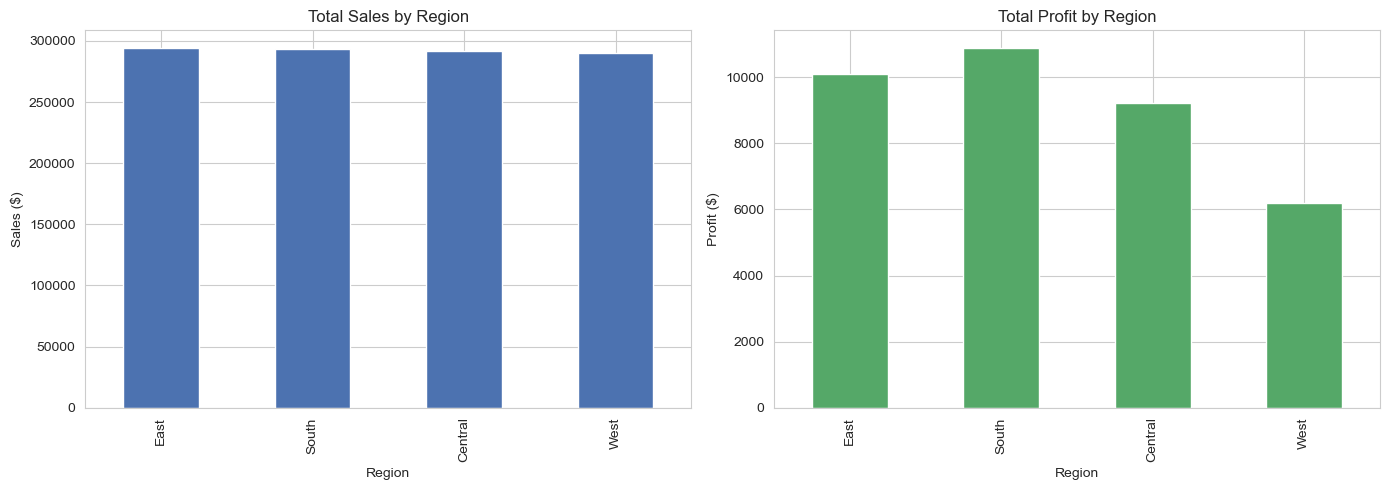

In [9]:
region_perf = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
display(region_perf)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
region_perf["Sales"].plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Total Sales by Region")
ax[0].set_ylabel("Sales ($)")

region_perf["Profit"].plot(kind="bar", ax=ax[1], color="#55A868")
ax[1].set_title("Total Profit by Region")
ax[1].set_ylabel("Profit ($)")
plt.tight_layout()
plt.show()

## Sales & Profit by Category / Sub-Category

,Sales,Profit
Category,,
Technology,670375.49,29715.93
Furniture,343778.83,-9755.28
Office Supplies,155337.04,16437.29


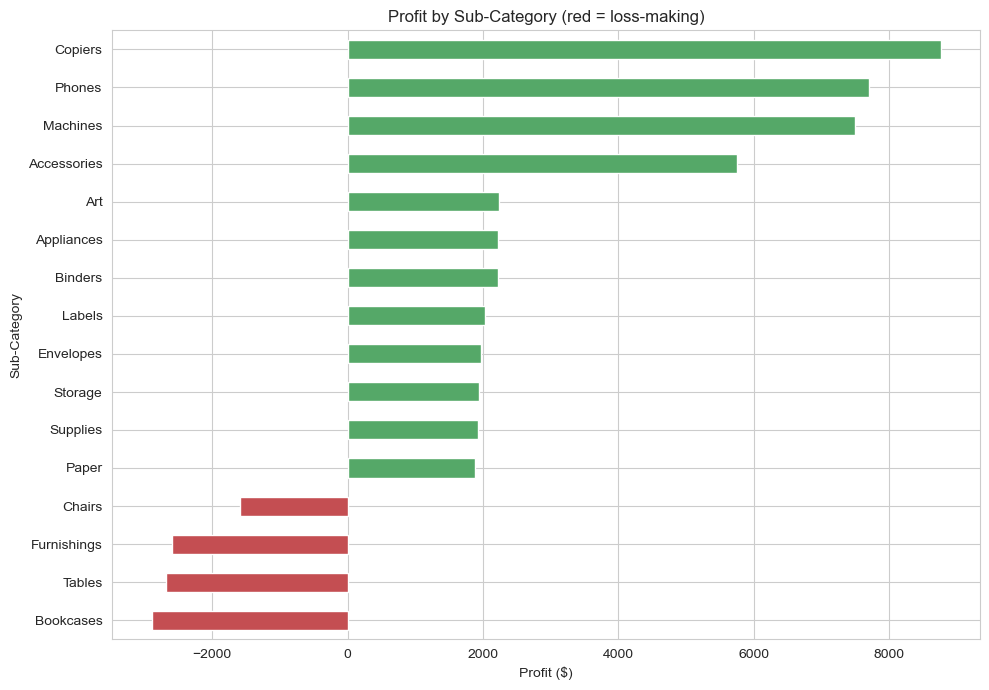

In [10]:
cat_perf = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
display(cat_perf)

subcat_perf = df.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values("Profit")

fig, ax = plt.subplots(figsize=(10, 7))
colors = subcat_perf["Profit"].apply(lambda x: "#C44E52" if x < 0 else "#55A868")
subcat_perf["Profit"].plot(kind="barh", ax=ax, color=colors)
ax.set_title("Profit by Sub-Category (red = loss-making)")
ax.set_xlabel("Profit ($)")
plt.tight_layout()
plt.show()

## Monthly Sales Trend


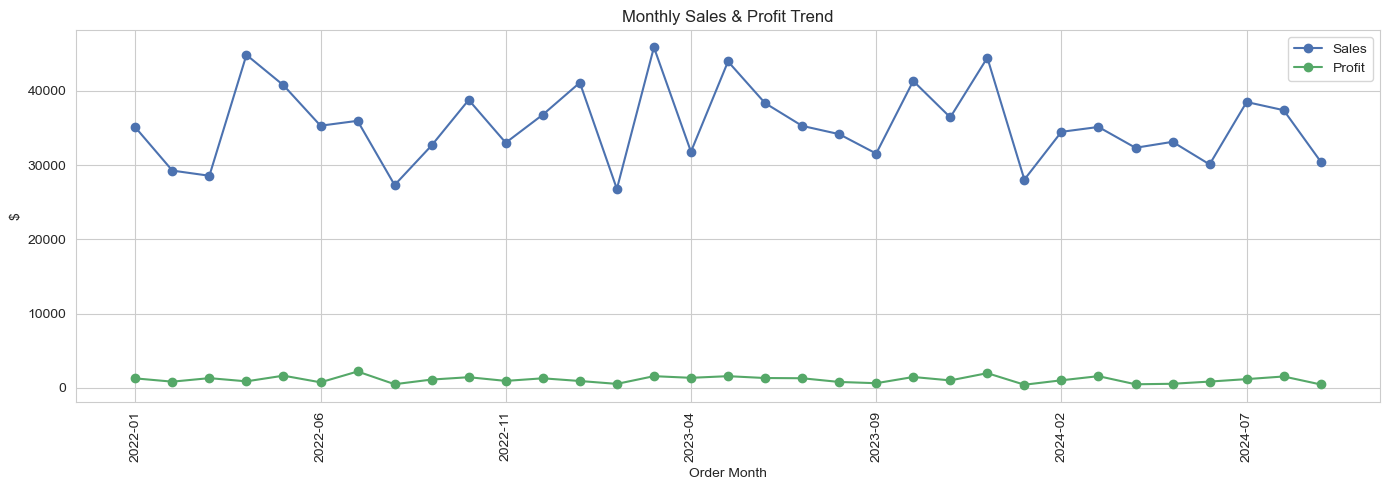

In [11]:
monthly = df.groupby("Order Month")[["Sales", "Profit"]].sum().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
monthly["Sales"].plot(ax=ax, marker="o", label="Sales", color="#4C72B0")
monthly["Profit"].plot(ax=ax, marker="o", label="Profit", color="#55A868")
ax.set_title("Monthly Sales & Profit Trend")
ax.set_ylabel("$")
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Top 5 Customers by Sales

Customer Name
Michael Martin        16798.63
Mary Thomas           16347.61
Susan Martinez        16132.60
Robert Lopez          14872.62
Jennifer Rodriguez    14451.91
Name: Sales, dtype: float64

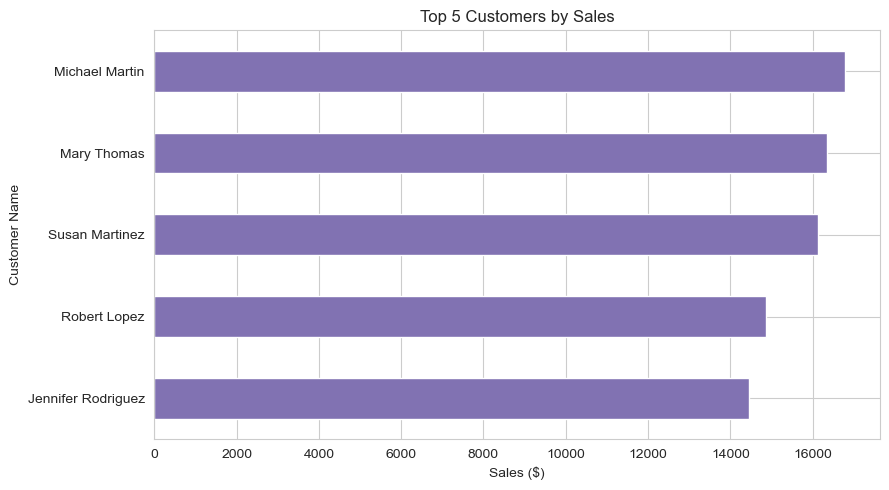

In [16]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)
display(top_customers)

fig, ax = plt.subplots(figsize=(9, 5))
top_customers.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Top 5 Customers by Sales")
ax.set_xlabel("Sales ($)")
plt.tight_layout()
plt.show()

## Discount vs. Profit Margin

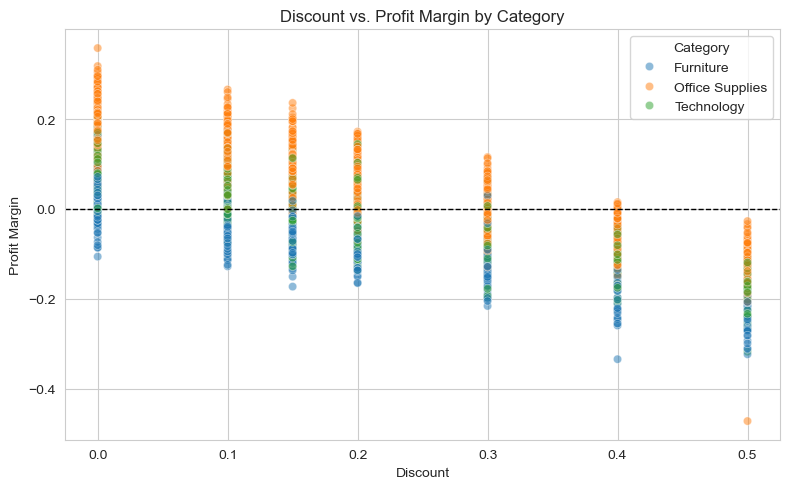

Category
Furniture         -0.842823
Office Supplies   -0.842802
Technology        -0.830742
Name: Profit Margin, dtype: float64

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="Discount", y="Profit Margin", hue="Category", alpha=0.5, ax=ax)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Discount vs. Profit Margin by Category")
plt.tight_layout()
plt.show()

df.groupby("Category")["Profit Margin"].corr(df["Discount"])

## Segment Performance

,Sales,Profit
Segment,,
Consumer,587974.59,20106.83
Corporate,350177.48,8184.96
Home Office,231339.29,8106.15


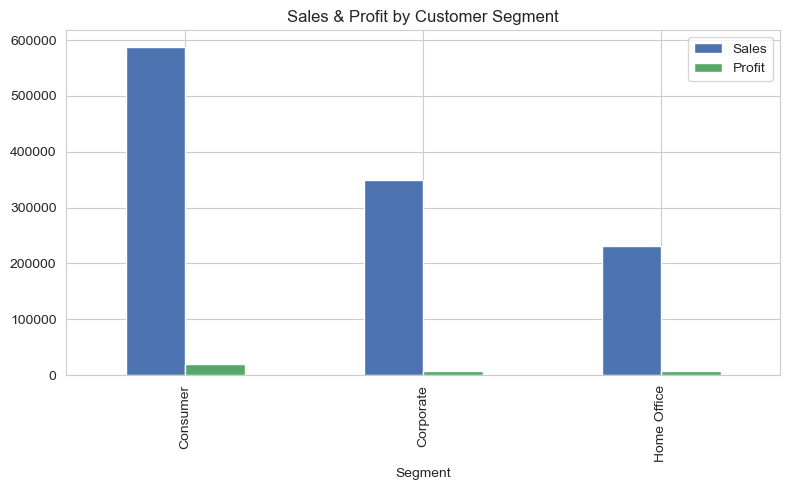

In [14]:
seg_perf = df.groupby("Segment")[["Sales", "Profit"]].sum()
display(seg_perf)

fig, ax = plt.subplots(figsize=(8, 5))
seg_perf.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868"])
ax.set_title("Sales & Profit by Customer Segment")
plt.tight_layout()
plt.show()


# Model Building & Evaluation

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = df[["Discount"]].values
y = df["Profit Margin"].values

model = LinearRegression()
model.fit(X, y)
preds = model.predict(X)

print(f"Coefficient (slope): {model.coef_[0]:.3f}")
print(f"Intercept:           {model.intercept_:.3f}")
print(f"R-squared:           {r2_score(y, preds):.3f}")
print(f"MAE:                 {mean_absolute_error(y, preds):.3f}")
print("\nInterpretation: every extra 10% of discount is associated with roughly "
      f"{model.coef_[0]*0.1*100:.1f} percentage points change in profit margin.")

Coefficient (slope): -0.611
Intercept:           0.140
R-squared:           0.543
MAE:                 0.058

Interpretation: every extra 10% of discount is associated with roughly -6.1 percentage points change in profit margin.


# Final Conclusion & Insights

Based on the EDA above:

1. **Regional performance is uneven.** Sales are fairly spread across regions, but
   profit contribution varies more — some regions generate high sales with thinner
   margins, signalling a need for region-specific pricing/discount strategy.
2. **Technology and Office Supplies are the profit engines**, while a handful of
   **Furniture sub-categories (e.g., Bookcases, Tables) run at a loss** — largely
   driven by heavy discounting on low base-margin items.
3. **Discounting has a clear negative relationship with profit margin.** Beyond a
   certain discount threshold, orders tend to become unprofitable — the linear fit
   above quantifies this and can inform a discount cap policy.
4. **Sales are concentrated among a small set of high-value customers** (see Top 5
   by Sales) — an 80/20-style pattern that supports targeted retention/loyalty efforts
   for top accounts.
5. **Segment mix matters**: Consumer segment drives the most orders, while Corporate/
   Home Office orders trend toward higher average order value.